# Data Preparation for Machine Learning

<div class='alert alert-info'>

:::{objectives}
- Provide an overview of data preparation.
- Load Penguins dataset.
- Use pandas and seaborn to analyze and visualize data.
- Identify and manage missing values and outliers in dataset.
- Encode categorical variables into numerical values suitable for ML models.
:::
</div>

<div class='alert alert-success'>

:::{instructor-note}
- 20 min teaching
- 20 min exercises/discussion
:::
</div>

In [Episode 2: Fundamentals of Machine Learning](./2-fundamentals-of-ml.ipynb), it is clearly shown that data preparation and processing often consume a significant portion of the ML workflow --- often more time than the actual model training, evaluation, and optimization. Cleaning, transforming, and structuring raw data into a usable format ensures that algorithms can efficiently extract valuable insights. Additionally, the choice of data formats, such as CSV for simplicity or HDF5 for large-scale datasets, can significantly impact data storage, accessibility, and computational efficiency during both model training and deployment.

In this episode, we will provide an overview of data preparation and introduce available public datasets. Using the [Palmer Penguins dataset](https://zenodo.org/records/3960218) as an example, we will offer demonstrations and hands-on exercises to develop a comprehensive understanding of data preparation including handling missing values and outliers, encoding categorical variables, and other essential preprocessing techniques for ML workflows.

## 1. What is Data Preparation

Data preparation refers to the process of cleaning, structuring, and transforming raw data into a structured, high-quality format ready for statistical analysis and ML. It’s one of the most critical steps in the ML workflow because high-quality data leads to better model performance.

Key procedures include:
- Collecting data from multiple sources,
- Handling missing values (imputation or removal),
- Detecting and treating outliers,
- Encoding categorical variables,
- Normalizing or scaling features,
- Feature selection and feature engineering.

## 2. Collecting Data from Multiple Sources

Data preparation begins with collecting raw data from a wide variety of sources, including databases, sensors, APIs, web scraping, surveys, and existing public datasets.

During the data collection process, it is important to ensure consistency and compatibility across all sources. Different sources may have different formats, units, naming conventions, or levels of quality. Careful integration, cleaning, and normalization are required to create a unified dataset suitable for analysis or modeling. Proper documentation of sources and collection methods is also essential to maintain reproducibility and data governance.

Public datasets provide an excellent resource for learning, experimentation, and benchmarking. Some widely used datasets across different domains include:
- Tabular datasets: Iris, **Penguins**, Titanic, Boston Housing, Wine, *etc.*
- Image datasets: [MNIST](https://en.wikipedia.org/wiki/MNIST_database), [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html), [CIFAR-100](https://www.cs.toronto.edu/~kriz/cifar.html), [COCO](https://cocodataset.org/#home), [ImageNet](https://www.image-net.org/index.php).
- Text datasets: [IMDB Reviews](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews), [20 Newsgroups](https://scikit-learn.org/0.19/datasets/twenty_newsgroups.html), [Sentiment140](https://www.tensorflow.org/datasets/catalog/sentiment140).
- Audio datasets: [LibriSpeech](https://www.openslr.org/12), [UrbanSound8K](https://urbansounddataset.weebly.com/urbansound8k.html), [ESC-50](https://www.kaggle.com/datasets/mmoreaux/environmental-sound-classification-50).
- Video datasets: [UCF101](https://www.crcv.ucf.edu/data/UCF101.php), [Kinetics](https://www.kaggle.com/datasets/rohanmallick/kinetics-train-5per), [HMDB51](https://www.kaggle.com/datasets/easonlll/hmdb51).

These datasets are available on platforms like [Kaggle](https://www.kaggle.com/), [UCI Machine Learning Repository](https://archive.ics.uci.edu/), [TensorFlow Datasets](https://www.tensorflow.org/datasets), and [Hugging Face Datasets](https://huggingface.co/docs/datasets/en/index), providing accessible resources for practice and innovation.

It should be noted that most of the data available by default is too raw to perform statistical analysis. Proper preprocessing is essential before the data can be used to identify meaningful patterns or to train models for prediction. In the following sections, we use the Penguins dataset as an example to demonstrate essential data preprocessing steps. These include handling missing values, detecting and treating outliers, encoding categorical variables, and performing other necessary transformations to prepare the dataset for ML tasks. Proper preprocessing ensures data quality, reduces bias, and improves the performance and reliability of the models we build.

## 3. Palmer Penguins Dataset

[Palmer Penguins dataset](https://zenodo.org/records/3960218) is a widely used open dataset in data science and ML education. This dataset contains information on three penguin species that inhabit islands near the Palmer Archipelago in Antarctica: Adelie, Chinstrap, and Gentoo. Each row in the dataset corresponds to a single penguin and records both physical measurements and categorical attributes. The key numerical features include flipper length (mm), culmen length and depth (bill measurements, in mm), and body mass (g). Alongside these, categorical variables such as species, island, and sex are provided.

These data were collected from 2007 - 2009 by Dr. Kristen Gorman with the [Palmer Station Long Term Ecological Research Program](https://lternet.edu/site/palmer-antarctica-lter/), part of the [US Long Term Ecological Research Network](https://lternet.edu/). It contains measurements for 344 penguins from three species -- Adelie, Chinstrap, and Gentoo -- collected from three islands (Biscoe, Dream, and Torgersen) in the Palmer Archipelago, Antarctica.

The data were imported directly from the [Environmental Data Initiative (EDI)](https://edirepository.org/) Data Portal, and are available for use by CC0 license (“No Rights Reserved”) in accordance with the [Palmer Station Data Policy](https://lternet.edu/data-access-policy/).

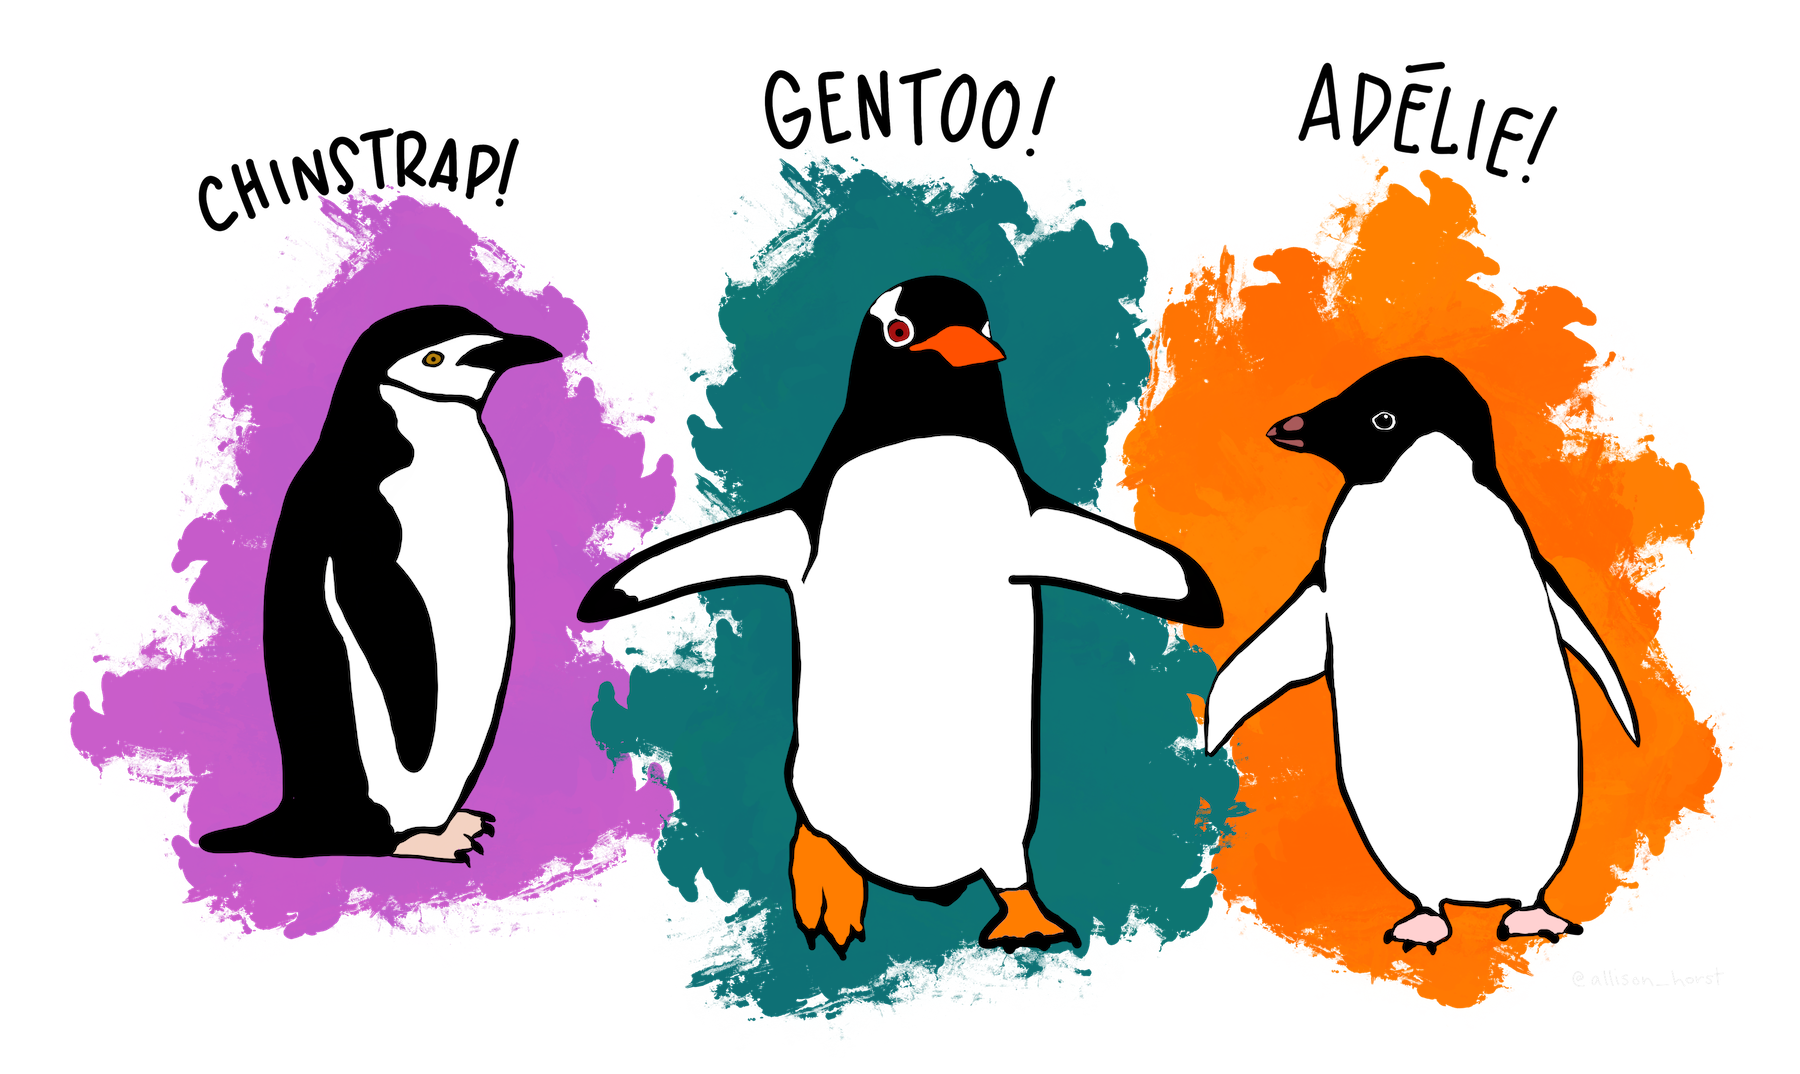

In [3]:
from IPython.display import Image, display
display(Image("../images/data/penguins.png", width=1240))

### 3.1 Loading Dataset

Seaborn provides the Penguins dataset through its built-in data-loading functions. We can access it using `sns.load_dataset('penguin')` and then have a quick look at the data.

<div class='alert alert-info'>

:::{note}
If you have your own dataset stored in a CSV file, you can easily load it into Python using Pandas with the `read_csv()` function. This is one of the most common ways to bring tabular data into a DataFrame for further analysis and processing.

Beyond CSV files, Pandas also supports a wide variety of other file formats, making it a powerful and flexible tool for data handling. For example, you can use `read_excel()` to import data from Microsoft Excel spreadsheets, `read_hdf()` to work with HDF5 binary stores, and `read_json()` to load data from JSON files. Each of these formats also has a corresponding method for saving data back to disk, such as `to_csv()`, `to_excel()`, `to_hdf()`, and `to_json()`.
:::
</div>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# penguins = pd.read_csv("./penguins_dataset.csv")

# URL of the Penguins dataset (CSV file)
# url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
# penguins = pd.read_csv(url)

penguins = sns.load_dataset('penguins')
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [3]:
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


There are seven columns include:
- *species*: penguin species (Adelie, Chinstrap, Gentoo)
- *island*: island where the penguin was found (Biscoe, Dream, Torgersen)
- *bill_length_mm*: length of the bill
- *bill_depth_mm*: depth of the bill
- *flipper_length_mm*: length of the flipper
- *body_mass_g*: body mass in grams
- *sex*: male or female

In [4]:
penguins.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


Looking only at the raw numbers in the `penguins` DataFrame, or even examining the statistical summaries provided by `penguins.info()` and `penguins.describe()`, often does not give us a clear intuition about the patterns and relationships in the data. To truly understand the dataset, we generally prefer to visualize the data, since graphical representations can reveal trends, groupings, and anomalies that may remain hidden in numerical summaries alone.

One nice visualization for datasets with relatively few attributes is **Pair Plot**, which can be created using `sns.pairplot(...)`. It shows a scatterplot of each attribute plotted against each of the other attributes. By using the `hue='species'` setting for the pairplot the graphs on the diagonal are layered kernel density estimate plots for the different values of the `species` column.

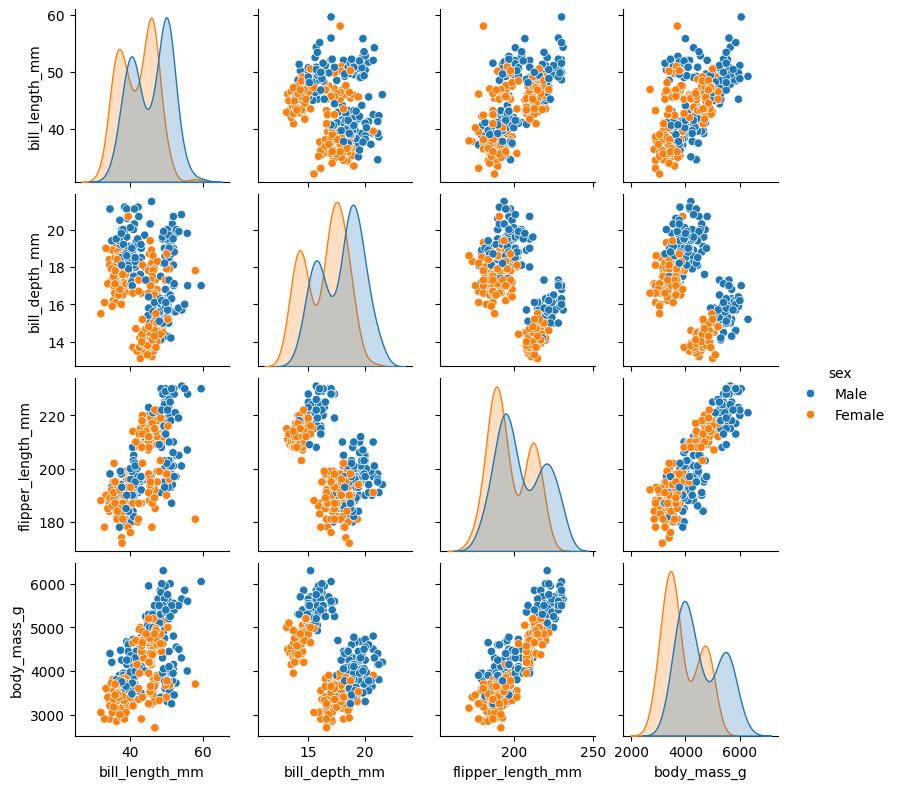

In [5]:
sns.pairplot(penguins, hue="sex", height=2.0)

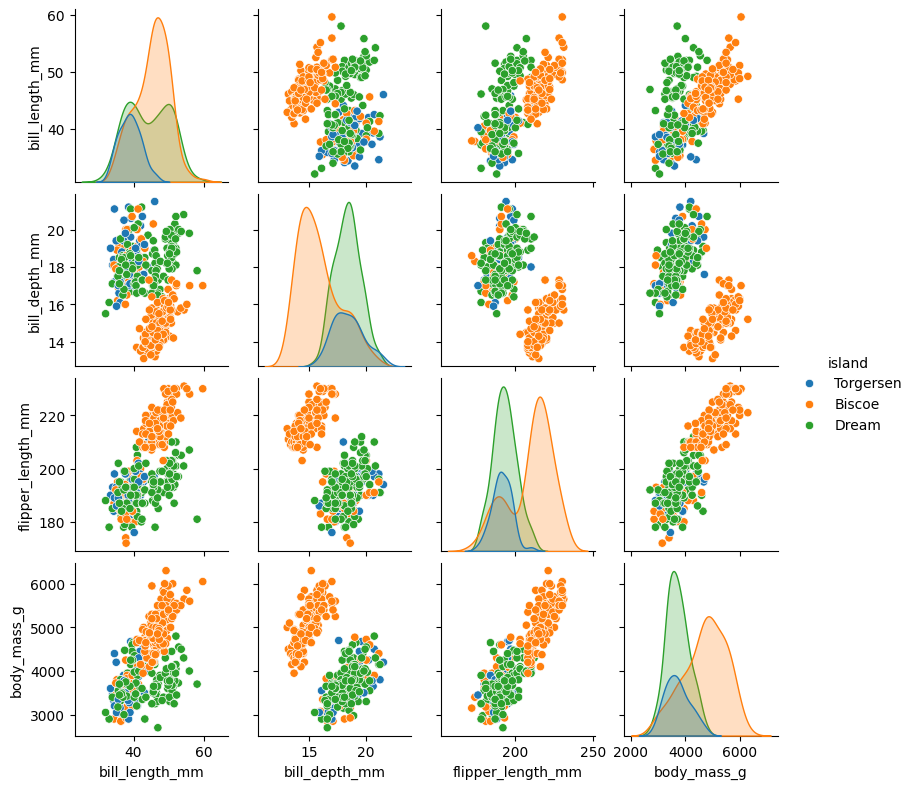

In [6]:
sns.pairplot(penguins, hue="island", height=2.0)

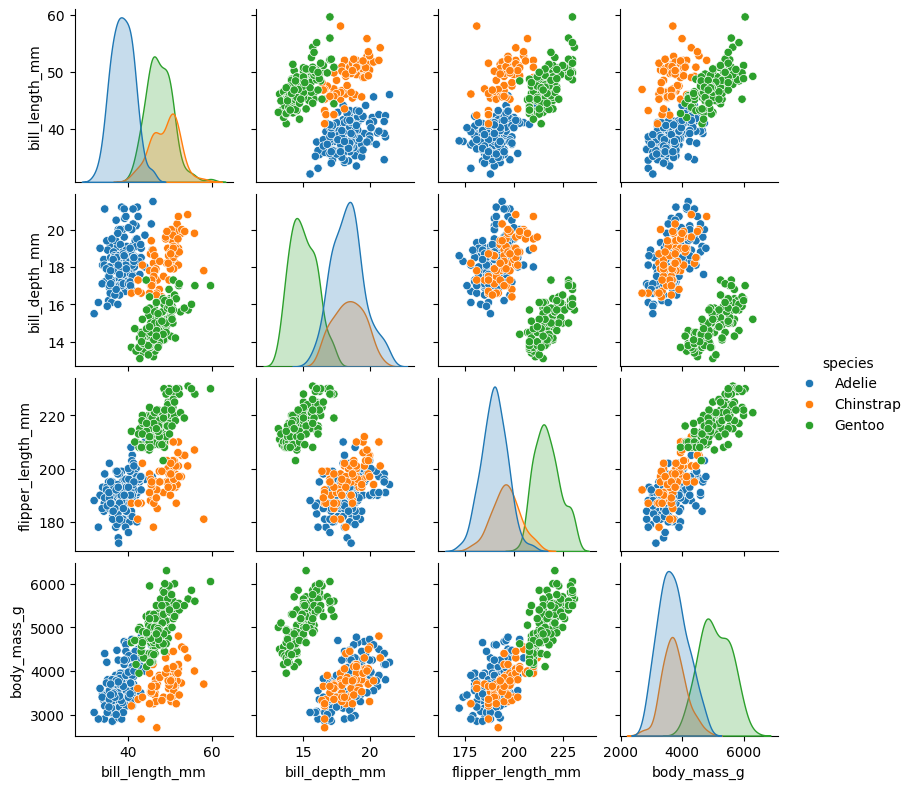

In [7]:
sns.pairplot(penguins[["species", "bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]], hue="species", height=2.0)

<div class='alert alert-success'>

:::{discussion}

Take a look at the pairplot we created. Consider the following questions:
- Is there any class that is easily distinguishable from the others?
- Which combination of attributes shows the best separation for all 3 class labels at once?
- For pairplot with ``hue="sex"``, which combination of features distinguishes the two sexes best?
- What about the one with ``hue="island"``? 
</div>

### 3.2 Handling Missing Values

Upon loading the Penguins dataset into a pandas DataFrame, the initial examination reveals the presence of `NaN` (Not a Number) values within several rows (highlighted in the Jupyter notebook). These placeholders explicitly indicate missing or unavailable data for certain measurements, such as bill length or the sex of particular penguins. Recognizing these missing values is an important first step, as they must be properly handled before performing any data analysis.

For numerical features such as bill length, bill depth, flipper length, and body mass, several strategies can be applied. A straightforward approach is to **remove any rows with missing values**, but this is often wasteful and reduces the sample size.

A more effective method is imputation: replacing missing numerical values with a suitable estimate. Common choices include the `mean` or `median` of the feature, depending on distribution.
Before applying imputation to handle missing numerical values, it is important to first identify where the NaN values occur in the dataset. We can run `penguins_test.style.highlight_null(color = 'red')`, where NaN values are hightlighed in the output.

In [8]:
penguins_test = pd.concat([penguins.head(5), penguins.tail(5)])
penguins_test.style.highlight_null(color = 'red')

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.100000,18.700000,181.000000,3750.000000,Male
1,Adelie,Torgersen,39.500000,17.400000,186.000000,3800.000000,Female
2,Adelie,Torgersen,40.300000,18.000000,195.000000,3250.000000,Female
3,Adelie,Torgersen,nan,nan,nan,nan,nan
4,Adelie,Torgersen,36.700000,19.300000,193.000000,3450.000000,Female
339,Gentoo,Biscoe,nan,nan,nan,nan,nan
340,Gentoo,Biscoe,46.800000,14.300000,215.000000,4850.000000,Female
341,Gentoo,Biscoe,50.400000,15.700000,222.000000,5750.000000,Male
342,Gentoo,Biscoe,45.200000,14.800000,212.000000,5200.000000,Female
343,Gentoo,Biscoe,49.900000,16.100000,213.000000,5400.000000,Male


#### 3.2.1 Handling missing numerical data

##### <mark>**Mean or Median Imputation**</mark>

Here we calculate `mean` and `median` values for numerical features. To illustrate this process, we take `body_mass_g` feature as an example.

In [9]:
body_mass_g_mean = penguins_test.body_mass_g.mean()
body_mass_g_median = penguins_test.body_mass_g.median()
print(f"  mean value of body_mass_g is {body_mass_g_mean}")
print(f"median value of body_mass_g is {body_mass_g_median}")

  mean value of body_mass_g is 4431.25
median value of body_mass_g is 4325.0


Rather than directly replacing missing values, we concatenate new columns containing `mean` and `median` values for the `body_mass_g` feature to end of Penguins dataset, and than visualize distribution of this feature.

In [10]:
penguins_test['BMG_mean'] = penguins_test.body_mass_g.fillna(body_mass_g_mean)
penguins_test['BMG_median'] = penguins_test.body_mass_g.fillna(body_mass_g_median)
penguins_test.style.highlight_null(color = 'green')

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,BMG_mean,BMG_median
0,Adelie,Torgersen,39.100000,18.700000,181.000000,3750.000000,Male,3750.000000,3750.000000
1,Adelie,Torgersen,39.500000,17.400000,186.000000,3800.000000,Female,3800.000000,3800.000000
2,Adelie,Torgersen,40.300000,18.000000,195.000000,3250.000000,Female,3250.000000,3250.000000
3,Adelie,Torgersen,nan,nan,nan,nan,nan,4431.250000,4325.000000
4,Adelie,Torgersen,36.700000,19.300000,193.000000,3450.000000,Female,3450.000000,3450.000000
339,Gentoo,Biscoe,nan,nan,nan,nan,nan,4431.250000,4325.000000
340,Gentoo,Biscoe,46.800000,14.300000,215.000000,4850.000000,Female,4850.000000,4850.000000
341,Gentoo,Biscoe,50.400000,15.700000,222.000000,5750.000000,Male,5750.000000,5750.000000
342,Gentoo,Biscoe,45.200000,14.800000,212.000000,5200.000000,Female,5200.000000,5200.000000
343,Gentoo,Biscoe,49.900000,16.100000,213.000000,5400.000000,Male,5400.000000,5400.000000


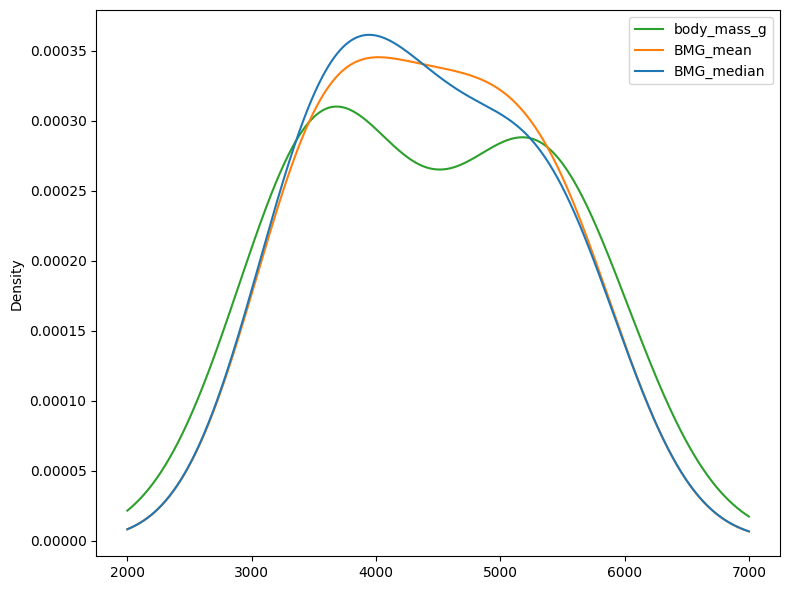

In [11]:
plt.figure(figsize=(8, 6))

penguins_test['body_mass_g'].plot(kind='kde', color='tab:green', label="body_mass_g")
penguins_test['BMG_mean'].plot(kind='kde', color='tab:orange', label="BMG_mean")
penguins_test['BMG_median'].plot(kind='kde', color='tab:blue', label="BMG_median")

plt.legend(loc='best')
plt.tight_layout()

##### <mark>**End of Distribution Imputation**</mark>

- Sometimes one would want to replace missing data with values at the tail of distribution of variable.
- Advantage is that it is quick and captures importance of missing values (if one suspects missing data is valuable).
- EoD's extreme value means the mean value with 3rd stander deviation, `(mean + (3*std))`)

In [12]:
eod_value = penguins_test['body_mass_g'].mean() + 3 * penguins_test['body_mass_g'].std()
eod_value

7358.515606085554

In [13]:
penguins_test['BMG_EoD'] = penguins_test.body_mass_g.fillna(eod_value)
penguins_test.style.highlight_null(color = 'green')

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,BMG_mean,BMG_median,BMG_EoD
0,Adelie,Torgersen,39.100000,18.700000,181.000000,3750.000000,Male,3750.000000,3750.000000,3750.000000
1,Adelie,Torgersen,39.500000,17.400000,186.000000,3800.000000,Female,3800.000000,3800.000000,3800.000000
2,Adelie,Torgersen,40.300000,18.000000,195.000000,3250.000000,Female,3250.000000,3250.000000,3250.000000
3,Adelie,Torgersen,nan,nan,nan,nan,nan,4431.250000,4325.000000,7358.515606
4,Adelie,Torgersen,36.700000,19.300000,193.000000,3450.000000,Female,3450.000000,3450.000000,3450.000000
339,Gentoo,Biscoe,nan,nan,nan,nan,nan,4431.250000,4325.000000,7358.515606
340,Gentoo,Biscoe,46.800000,14.300000,215.000000,4850.000000,Female,4850.000000,4850.000000,4850.000000
341,Gentoo,Biscoe,50.400000,15.700000,222.000000,5750.000000,Male,5750.000000,5750.000000,5750.000000
342,Gentoo,Biscoe,45.200000,14.800000,212.000000,5200.000000,Female,5200.000000,5200.000000,5200.000000
343,Gentoo,Biscoe,49.900000,16.100000,213.000000,5400.000000,Male,5400.000000,5400.000000,5400.000000


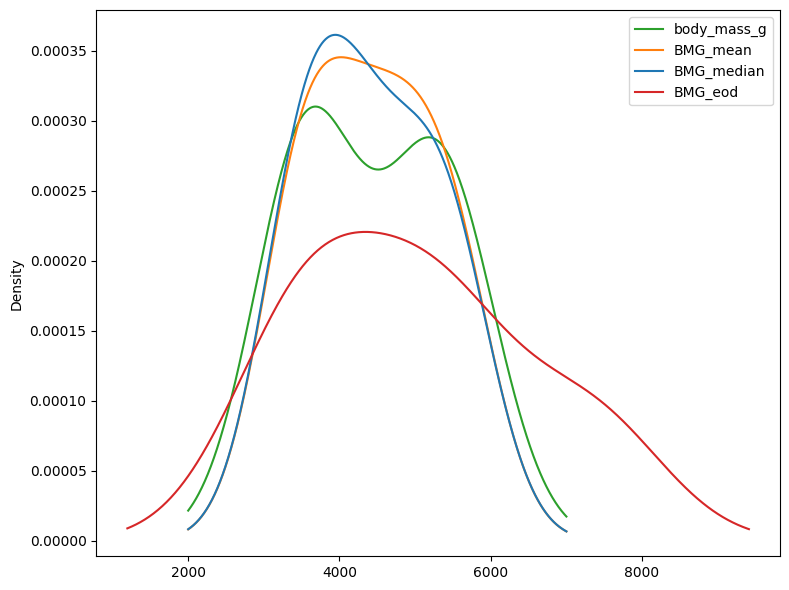

In [14]:
plt.figure(figsize=(8, 6))

penguins_test['body_mass_g'].plot(kind='kde', color='tab:green', label="body_mass_g")
penguins_test['BMG_mean'].plot(kind='kde', color='tab:orange', label="BMG_mean")
penguins_test['BMG_median'].plot(kind='kde', color='tab:blue', label="BMG_median")
penguins_test['BMG_EoD'].plot(kind='kde', color='tab:red', label="BMG_eod")

plt.legend(loc='best')
plt.tight_layout()

<div class='alert alert-warning'>

:::{warning}
In certain scenarios, imputing missing data with values at **end of distribution** (EoD) of a variable can be a considered strategy. This approach offers advantage of computational speed and can theoretically capture significance of missing entries. Typically, EoD is calculated as an extreme value such as `mean + 3*std`, where `mean` and `std` of feature can be obtained using `.describe()` method.

However, as demonstrated here, this type of imputation often generates unrealistic values and distorts original distribution, particularly for features like `body_mass_g`. Consequently, it can lead to biased analyses and should be used with caution.
:::
</div>

#### 3.2.2 Handling missing categorical data

In [15]:
penguins_test = pd.concat([penguins.head(5), penguins.tail(5)])
penguins_test.style.highlight_null(color = 'red')

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.100000,18.700000,181.000000,3750.000000,Male
1,Adelie,Torgersen,39.500000,17.400000,186.000000,3800.000000,Female
2,Adelie,Torgersen,40.300000,18.000000,195.000000,3250.000000,Female
3,Adelie,Torgersen,nan,nan,nan,nan,nan
4,Adelie,Torgersen,36.700000,19.300000,193.000000,3450.000000,Female
339,Gentoo,Biscoe,nan,nan,nan,nan,nan
340,Gentoo,Biscoe,46.800000,14.300000,215.000000,4850.000000,Female
341,Gentoo,Biscoe,50.400000,15.700000,222.000000,5750.000000,Male
342,Gentoo,Biscoe,45.200000,14.800000,212.000000,5200.000000,Female
343,Gentoo,Biscoe,49.900000,16.100000,213.000000,5400.000000,Male


For categorical features such as sex, approach differs.
- One simple method is to replace missing categories with most frequent value (`mode`), which assumes missing value follows majority distribution.
- Alternatively, missing values can be treated as a separate category, labeled for example as "Unknown" or "Missing" which allows models to learn if missingness itself carries information.
- Another option is to apply model-based imputation, where missing categorical values are predicted from other features using classification algorithms.

##### <mark>**Imputation with most frequent value (`mode`)**</mark>

mode for sex feature: 
 0    Female
Name: sex, dtype: object


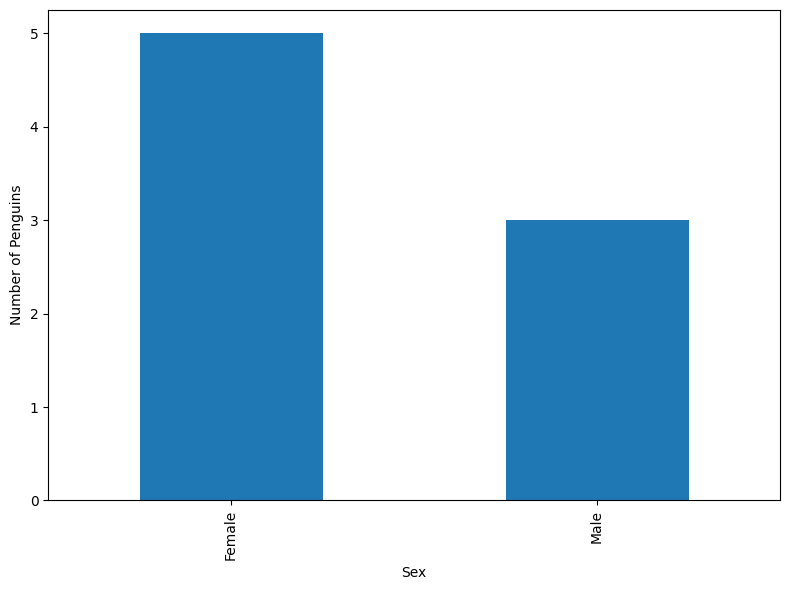

In [16]:
plt.figure(figsize=(8, 6))
penguins_test.sex.value_counts().sort_values(ascending=False).plot.bar()
plt.xlabel('Sex')
plt.ylabel('Number of Penguins')
plt.tight_layout()

print("mode for sex feature: \n", penguins_test.sex.mode())

In [17]:
penguins_test['Sex_mode'] = penguins_test['sex'].fillna(penguins_test.sex.mode()[0])
penguins_test.style.highlight_null(color = 'green')

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,Sex_mode
0,Adelie,Torgersen,39.100000,18.700000,181.000000,3750.000000,Male,Male
1,Adelie,Torgersen,39.500000,17.400000,186.000000,3800.000000,Female,Female
2,Adelie,Torgersen,40.300000,18.000000,195.000000,3250.000000,Female,Female
3,Adelie,Torgersen,nan,nan,nan,nan,nan,Female
4,Adelie,Torgersen,36.700000,19.300000,193.000000,3450.000000,Female,Female
339,Gentoo,Biscoe,nan,nan,nan,nan,nan,Female
340,Gentoo,Biscoe,46.800000,14.300000,215.000000,4850.000000,Female,Female
341,Gentoo,Biscoe,50.400000,15.700000,222.000000,5750.000000,Male,Male
342,Gentoo,Biscoe,45.200000,14.800000,212.000000,5200.000000,Female,Female
343,Gentoo,Biscoe,49.900000,16.100000,213.000000,5400.000000,Male,Male


##### <mark>**Imputation with constant value**</mark>

In [18]:
penguins_test['Sex_ConstValue'] = penguins_test['sex'].fillna("Missing")
penguins_test.style.highlight_null(color = 'green')

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,Sex_mode,Sex_ConstValue
0,Adelie,Torgersen,39.100000,18.700000,181.000000,3750.000000,Male,Male,Male
1,Adelie,Torgersen,39.500000,17.400000,186.000000,3800.000000,Female,Female,Female
2,Adelie,Torgersen,40.300000,18.000000,195.000000,3250.000000,Female,Female,Female
3,Adelie,Torgersen,nan,nan,nan,nan,nan,Female,Missing
4,Adelie,Torgersen,36.700000,19.300000,193.000000,3450.000000,Female,Female,Female
339,Gentoo,Biscoe,nan,nan,nan,nan,nan,Female,Missing
340,Gentoo,Biscoe,46.800000,14.300000,215.000000,4850.000000,Female,Female,Female
341,Gentoo,Biscoe,50.400000,15.700000,222.000000,5750.000000,Male,Male,Male
342,Gentoo,Biscoe,45.200000,14.800000,212.000000,5200.000000,Female,Female,Female
343,Gentoo,Biscoe,49.900000,16.100000,213.000000,5400.000000,Male,Male,Male


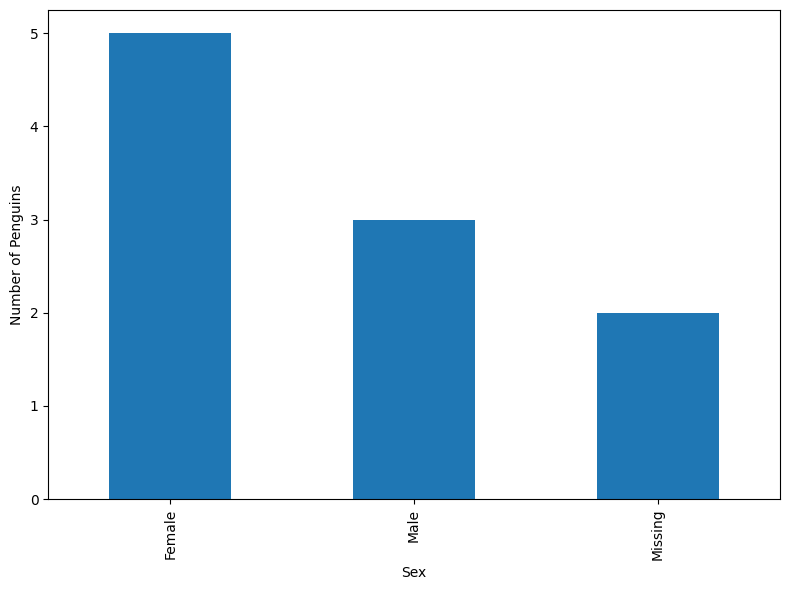

In [19]:
plt.figure(figsize=(8, 6))
penguins_test["Sex_ConstValue"].value_counts().sort_values(ascending=False).plot.bar()
plt.xlabel('Sex')
plt.ylabel('Number of Penguins')
plt.tight_layout()

<div class='alert alert-info'>

:::{note}
For the other dataset, strategy for handling missing values is not one-size-fits-all; it depends heavily on whether missing data is numerical or categorical and underlying mechanism causing data to be missing. Ignoring these missing entries, such as by simply dropping affected rows, may introduce significant bias, reduce statistical power, and ultimately lead to inaccurate or misleading conclusions.

After any imputation, it is essential to perform sanity checks to ensure the imputed values are plausible and to document the methodology transparently. Properly handling missing data in this way transforms an incomplete dataset into a robust and reliable foundation for generating accurate insights and building powerful predictive models.
:::
</div>

#### 3.2.3 Remove missing values

For all ML tasks we will perform in the following episodes, we adopt a straightforward approach of removing any rows that contain missing values (`penguins_test.dropna()`). This ensures that the dataset is complete and avoids potential errors or biases caused by NaN entries. Although more sophisticated imputation methods exist, dropping rows is a simple and effective strategy when the proportion of missing data is relatively small.

In [20]:
penguins_test = pd.concat([penguins.head(5), penguins.tail(5)])
penguins_test.style.highlight_null(color = 'red')

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.100000,18.700000,181.000000,3750.000000,Male
1,Adelie,Torgersen,39.500000,17.400000,186.000000,3800.000000,Female
2,Adelie,Torgersen,40.300000,18.000000,195.000000,3250.000000,Female
3,Adelie,Torgersen,nan,nan,nan,nan,nan
4,Adelie,Torgersen,36.700000,19.300000,193.000000,3450.000000,Female
339,Gentoo,Biscoe,nan,nan,nan,nan,nan
340,Gentoo,Biscoe,46.800000,14.300000,215.000000,4850.000000,Female
341,Gentoo,Biscoe,50.400000,15.700000,222.000000,5750.000000,Male
342,Gentoo,Biscoe,45.200000,14.800000,212.000000,5200.000000,Female
343,Gentoo,Biscoe,49.900000,16.100000,213.000000,5400.000000,Male


In [21]:
penguins_test_remove = penguins_test.dropna() # axis=1
penguins_test_remove.style.highlight_null(color = 'red')

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.100000,18.700000,181.000000,3750.000000,Male
1,Adelie,Torgersen,39.500000,17.400000,186.000000,3800.000000,Female
2,Adelie,Torgersen,40.300000,18.000000,195.000000,3250.000000,Female
4,Adelie,Torgersen,36.700000,19.300000,193.000000,3450.000000,Female
340,Gentoo,Biscoe,46.800000,14.300000,215.000000,4850.000000,Female
341,Gentoo,Biscoe,50.400000,15.700000,222.000000,5750.000000,Male
342,Gentoo,Biscoe,45.200000,14.800000,212.000000,5200.000000,Female
343,Gentoo,Biscoe,49.900000,16.100000,213.000000,5400.000000,Male


### 3.3. Handling Outliers

Outliers are values that are too far from rest of observations in columns. For instance, if body mass of most of penguins in dataset varies between 3000-6000 g, an observation of 7500 g will be considered as an outlier since such an observation occurs rarely.

#### 3.3.1 Creating outliers

We have calculated EoD value of `body_mass_g` feature and then check if this value is outlier for this feature. 

In [39]:
# Here we use the EoD value as an example to create two outlier points

penguins_test_BMG_outlier = penguins[["species", "bill_length_mm", "body_mass_g"]]

eod_value = penguins_test['body_mass_g'].mean() + 3 * penguins_test['body_mass_g'].std()
print(f"EoD value = {eod_value}")

penguins_test_BMG_outlier.loc[:, "body_mass_g"] = penguins_test_BMG_outlier["body_mass_g"].fillna(eod_value)
penguins_test_BMG_outlier

EoD value = 7358.515606085554


,species,bill_length_mm,body_mass_g
0,Adelie,39.1,3750.000000
1,Adelie,39.5,3800.000000
2,Adelie,40.3,3250.000000
3,Adelie,NaN,7358.515606
4,Adelie,36.7,3450.000000
...,...,...,...
339,Gentoo,NaN,7358.515606
340,Gentoo,46.8,4850.000000
341,Gentoo,50.4,5750.000000
342,Gentoo,45.2,5200.000000


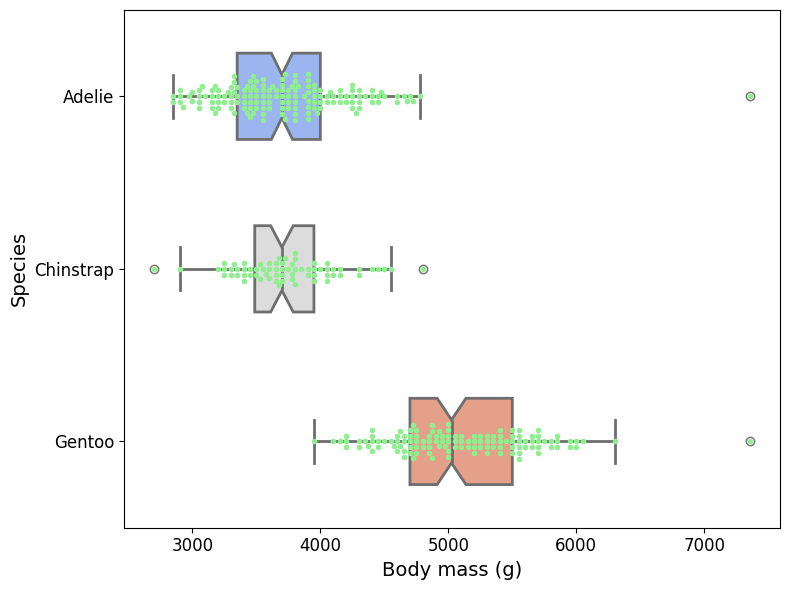

In [23]:
plt.figure(figsize=(8,6))

sns.swarmplot(y=penguins_test_BMG_outlier["species"], x=penguins_test_BMG_outlier["body_mass_g"],
              color="lightgreen", marker="o", size=4)

sns.boxplot(y=penguins_test_BMG_outlier["species"], x=penguins_test_BMG_outlier["body_mass_g"], 
            palette="coolwarm", notch=True, linewidth=2, width=0.5, 
            hue=penguins_test_BMG_outlier.species, legend=False)

plt.xlabel("Body mass (g)", fontsize=14)
plt.ylabel("Species", fontsize=14)
plt.tick_params(axis='x', labelsize=12)
plt.tick_params(axis='y', labelsize=12)

plt.tight_layout()

There are several approaches to identify outliers, and two of most commonly used methods are **Interquartile Range (IQR)** method and **Mean-Standard Deviation** method.

#### 3.3.2 The Inter quartile range (IQR) method

IQR measures spread of middle 50% of data and is calculated by subtracting 1st quartile (25th percentile, Q1) from 3rd quartile (75th percentile, Q3).
- Once IQR is obtained, we can determine boundaries for detecting outliers.
- Lower limit is defined as Q1 minus 1.5 times IQR.
- Upper limit is defined as Q3 plus 1.5 times IQR.

In [24]:
penguins_test_BMG_outlier.describe()

,bill_length_mm,body_mass_g
count,342.000000,344.000000
mean,43.921930,4220.107649
std,5.459584,834.954489
min,32.100000,2700.000000
25%,39.225000,3550.000000
50%,44.450000,4050.000000
75%,48.500000,4781.250000
max,59.600000,7358.515606


In [40]:
print(f"25% quantile = {penguins_test_BMG_outlier['body_mass_g'].quantile(0.25)}")
print(f"75% quantile = {penguins_test_BMG_outlier['body_mass_g'].quantile(0.75)}\n")

IQR = penguins_test_BMG_outlier["body_mass_g"].quantile(0.75) - penguins_test_BMG_outlier["body_mass_g"].quantile(0.25)
lower_bmg_limit = penguins_test_BMG_outlier["body_mass_g"].quantile(0.25) - (1.5 * IQR)
upper_bmg_limit = penguins_test_BMG_outlier["body_mass_g"].quantile(0.75) + (1.5 * IQR)

print(f"lower limt of IQR = {lower_bmg_limit} and upper limit of IQR = {upper_bmg_limit}")

25% quantile = 3550.0
75% quantile = 4781.25

lower limt of IQR = 1703.125 and upper limit of IQR = 6628.125


Any data points that fall below lower limit or above upper limit are considered outliers, and these points are subsequently removed from dataset.

In [26]:
# check data points larger than the upper limit of the IQR range

penguins_test_BMG_outlier[penguins_test_BMG_outlier["body_mass_g"] > upper_bmg_limit]

,species,bill_length_mm,body_mass_g
3,Adelie,NaN,7358.515606
339,Gentoo,NaN,7358.515606


In [27]:
# check data points smaller than the lower limit of the IQR range

penguins_test_BMG_outlier[penguins_test_BMG_outlier["body_mass_g"] < lower_bmg_limit]

,species,bill_length_mm,body_mass_g


In [28]:
# remove the outliers

penguins_test_BMG_outlier_remove_IQR = penguins_test_BMG_outlier[penguins_test_BMG_outlier["body_mass_g"] < upper_bmg_limit]
penguins_test_BMG_outlier_remove_IQR

,species,bill_length_mm,body_mass_g
0,Adelie,39.1,3750.0
1,Adelie,39.5,3800.0
2,Adelie,40.3,3250.0
4,Adelie,36.7,3450.0
5,Adelie,39.3,3650.0
...,...,...,...
338,Gentoo,47.2,4925.0
340,Gentoo,46.8,4850.0
341,Gentoo,50.4,5750.0
342,Gentoo,45.2,5200.0


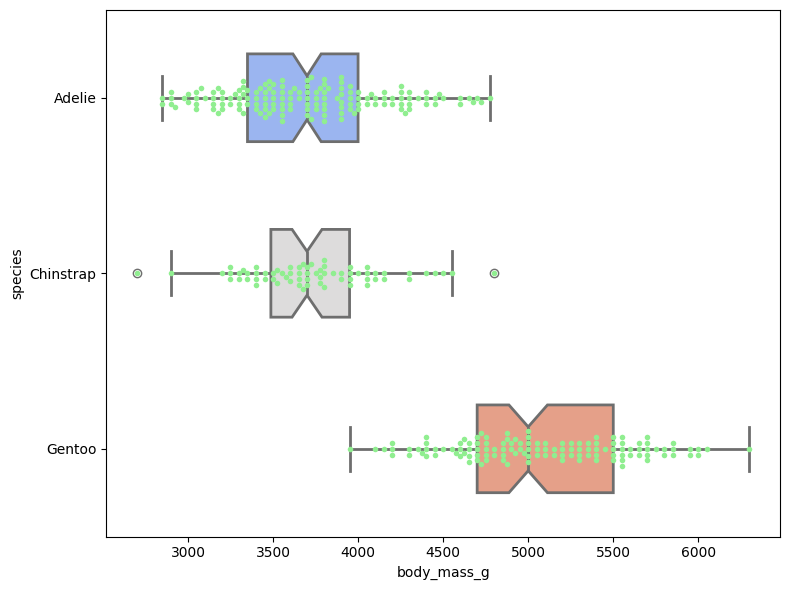

In [29]:
plt.figure(figsize=(8, 6))

sns.swarmplot(y=penguins_test_BMG_outlier_remove_IQR["species"], x=penguins_test_BMG_outlier_remove_IQR["body_mass_g"], color="lightgreen", marker="o", size=4)

sns.boxplot(y=penguins_test_BMG_outlier_remove_IQR["species"], x=penguins_test_BMG_outlier_remove_IQR["body_mass_g"], 
            palette="coolwarm", notch=True, linewidth=2, width=0.5, 
            hue=penguins_test_BMG_outlier_remove_IQR.species, legend=False)

plt.tight_layout()

#### 3.3.3 The mean-standard deviation method

Instead of using IQR method, upper and lower thresholds for detecting outliers can also be calculated with mean-std deviation approach.
- Here we compute `mean` and `std` of `body_mass_g` feature.
- Calculate upper and lower limits for outlier detection using formulas.
	- `lower limit = mean - 3.0 \times std`
	- `upper limit = mean + 3.0 \times std`
- Identify outliers and replace them with either `mean` or `median` values of `body_mass_g` feature.

In [30]:
penguins_test_BMG_outlier

,species,bill_length_mm,body_mass_g
0,Adelie,39.1,3750.000000
1,Adelie,39.5,3800.000000
2,Adelie,40.3,3250.000000
3,Adelie,NaN,7358.515606
4,Adelie,36.7,3450.000000
...,...,...,...
339,Gentoo,NaN,7358.515606
340,Gentoo,46.8,4850.000000
341,Gentoo,50.4,5750.000000
342,Gentoo,45.2,5200.000000


In [31]:
# calculate mean and std values

mean = penguins_test_BMG_outlier["body_mass_g"].mean()
std = penguins_test_BMG_outlier["body_mass_g"].std()
print(f"mean = {mean}, std = {std}", '\n')

lower_bmg_limit = mean - (3.0 * std)
upper_bmg_limit = mean + (3.0 * std)

print(f"lower limt of mean-std = {lower_bmg_limit} and upper limit of mean-std = {upper_bmg_limit}")

mean = 4220.10764887259, std = 834.9544887876802 

lower limt of mean-std = 1715.2441825095493 and upper limit of mean-std = 6724.971115235631


In [32]:
# check data points larger than the upper limit of the mean-std range

penguins_test_BMG_outlier[penguins_test_BMG_outlier["body_mass_g"] > upper_bmg_limit]

,species,bill_length_mm,body_mass_g
3,Adelie,NaN,7358.515606
339,Gentoo,NaN,7358.515606


In [33]:
# check data points smaller than the lower limit of the mean-std range

penguins_test_BMG_outlier[penguins_test_BMG_outlier["body_mass_g"] < lower_bmg_limit]

,species,bill_length_mm,body_mass_g


In [34]:
# we can remove these outliers, here we imputate these outliers with mean value of "body_mass_g" feature

penguins_test_BMG_outlier.loc[penguins_test_BMG_outlier["body_mass_g"] < lower_bmg_limit, "body_mass_g"] = mean
penguins_test_BMG_outlier.loc[penguins_test_BMG_outlier["body_mass_g"] > upper_bmg_limit, "body_mass_g"] = mean
penguins_test_BMG_outlier

,species,bill_length_mm,body_mass_g
0,Adelie,39.1,3750.000000
1,Adelie,39.5,3800.000000
2,Adelie,40.3,3250.000000
3,Adelie,NaN,4220.107649
4,Adelie,36.7,3450.000000
...,...,...,...
339,Gentoo,NaN,4220.107649
340,Gentoo,46.8,4850.000000
341,Gentoo,50.4,5750.000000
342,Gentoo,45.2,5200.000000


<div class='alert alert-info'>

:::{callout} There are four main techniques for handling outliers in a dataset.

- Remove outliers entirely.
    - This approach simply deletes rows containing outlier values, which can be effective if outliers are errors or rare events that are not relevant to analysis.
- Treat outliers as missing values.
    - Outliers can be replaced with `NaN` and then handled using imputation methods described in previous sections, such as replacing them with `mean`, `median`, or `mode`.
- Apply discretization or binning.
    - By grouping numerical values into bins, outliers are included in tail bins along with other extreme values, which reduces their impact while preserving overall structure of data.
- Cap or censor outliers.
    - Extreme values can be limited to a maximum or minimum threshold, often derived from statistical techniques such as IQR or standard deviation limits. This approach reduces influence of outliers without completely removing them from dataset.
:::
</div>

### 3.4 Encoding Categorical Variables

In previous sections, we adopted a straightforward approach to handling missing values by simply removing any rows that contained `NaN` values, whether they were in numerical or categorical features. While this step gives us a cleaner dataset, it is not sufficient on its own to proceed with ML tasks.

The reason is that most ML algorithms are designed to work only with numerical data. They cannot directly process textual or symbolic categories such as species, island, or sex in the Penguins dataset. To make these categorical variables usable in modeling, we need to encode categorical variables into a numerical format while preserving their information.

There are two widely used encoding techniques: **One-hot encoding (OHE)** and **Label Encoding**.

In [35]:
penguins_sex = penguins[["species", "island", "sex"]].head(10)
penguins_sex

,species,island,sex
0,Adelie,Torgersen,Male
1,Adelie,Torgersen,Female
2,Adelie,Torgersen,Female
3,Adelie,Torgersen,NaN
4,Adelie,Torgersen,Female
5,Adelie,Torgersen,Male
6,Adelie,Torgersen,Female
7,Adelie,Torgersen,Male
8,Adelie,Torgersen,NaN
9,Adelie,Torgersen,NaN


#### 3.4.1 One hot encoding (OHE)

OHE method creates a new binary column for each category in a feature. For example, species feature with values {Female, Male, and NaN} would be transformed into three new columns, each indicating presence (1) or absence (0) of that category for a given row.

In [36]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)  # `sparse_output=False` to get a dense array
encoded = encoder.fit_transform(penguins_sex[['sex']])

encoded = pd.DataFrame(encoded, columns=["Female", "Male", "NaN"])

penguins_sex_onehotencoding = pd.concat([penguins_sex, encoded], axis=1)
penguins_sex_onehotencoding

,species,island,sex,Female,Male,NaN
0,Adelie,Torgersen,Male,0.0,1.0,0.0
1,Adelie,Torgersen,Female,1.0,0.0,0.0
2,Adelie,Torgersen,Female,1.0,0.0,0.0
3,Adelie,Torgersen,NaN,0.0,0.0,1.0
4,Adelie,Torgersen,Female,1.0,0.0,0.0
5,Adelie,Torgersen,Male,0.0,1.0,0.0
6,Adelie,Torgersen,Female,1.0,0.0,0.0
7,Adelie,Torgersen,Male,0.0,1.0,0.0
8,Adelie,Torgersen,NaN,0.0,0.0,1.0
9,Adelie,Torgersen,NaN,0.0,0.0,1.0


<div class='alert alert-warning'>

:::{warning}
OHE works well when number of categories is small and when categories are unordered. However, it can lead to very large datasets if a feature contains many unique categories (high cardinality), such as a 'city' feature in Sweden. Sweden has nearly 300 municipalities and many more towns and localities. If each unique city is turned into its own column, dataset could quickly expand to hundreds of columns, most of which will contain zeros for any given row. This high cardinality increases memory usage, slows down training, and may reduce model’s efficiency.
:::
</div>

#### 3.4.2 Label encoding

Label encoding transforms a categorical feature into a single numerical column by assigning a unique integer to each category in a feature. For example, sex feature with values {Female, Male, NaN} could be encoded as Female = 0, Male = 1, and missing values handled separately or imputed beforehand (in our case, NaN is encoded as  NaN = 2).

In [37]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
encoded = encoder.fit_transform(penguins_sex['sex'])
encoded = pd.DataFrame(encoded, columns=["sex_LE"])

penguins_sex_labelencoding = pd.concat([penguins_sex, encoded], axis=1)
penguins_sex_labelencoding

,species,island,sex,sex_LE
0,Adelie,Torgersen,Male,1
1,Adelie,Torgersen,Female,0
2,Adelie,Torgersen,Female,0
3,Adelie,Torgersen,NaN,2
4,Adelie,Torgersen,Female,0
5,Adelie,Torgersen,Male,1
6,Adelie,Torgersen,Female,0
7,Adelie,Torgersen,Male,1
8,Adelie,Torgersen,NaN,2
9,Adelie,Torgersen,NaN,2


Unlike OHE, which creates multiple columns, label encoding produces only one column, making it more memory-efficient. However, it introduces an artificial ordinal relationship between categories (*e.g.*, implying Dream > Biscoe), which may not be meaningful and can affect algorithms that assume numeric order matters, such as linear regression or distance-based methods.

#### 3.4.3 The `get_dummies()` function in Pandas

In addition to OHE and LE methods, we can also use `get_dummies()` in Pandas to handle categorical variables by converting them into a one-hot encoded (dummy variable) format.

<div class='alert alert-info'>

:::{note}
This function ignores `NaN` values by default (it simply leaves them out).
:::
</div>

In [38]:
dummy_encoded = pd.get_dummies(penguins_sex['sex']).astype(np.int8)
penguins_sex_dummyencoding = pd.concat([penguins_sex, dummy_encoded], axis=1)
penguins_sex_dummyencoding

,species,island,sex,Female,Male
0,Adelie,Torgersen,Male,0,1
1,Adelie,Torgersen,Female,1,0
2,Adelie,Torgersen,Female,1,0
3,Adelie,Torgersen,NaN,0,0
4,Adelie,Torgersen,Female,1,0
5,Adelie,Torgersen,Male,0,1
6,Adelie,Torgersen,Female,1,0
7,Adelie,Torgersen,Male,0,1
8,Adelie,Torgersen,NaN,0,0
9,Adelie,Torgersen,NaN,0,0


<div class='alert alert-info'>

:::{callout} More encoding strategies
Beyond these two common methods, there are several other encoding strategies, especially useful for more complex datasets:
- **Ordinal Encoding**: A variation of label encoding designed specifically for variables that have a natural and meaningful order (*e.g.*, Small = 0, Medium = 1, Large = 2).
- **Binary Encoding**: Converts categories into binary code, achieving a good compromise between one-hot and label encoding for high-cardinality data.
- **Target Encoding** (Mean Encoding): Replaces each category with the average value of the target variable for that category. It is powerful but prone to overfitting if not carefully implemented.
- **Frequency Encoding**: Replaces categories with their frequency of occurrence in the dataset. This can be useful for dealing with high-cardinality features.

The choice of encoding method is a consequential modeling decision. It should be guided by the type of categorical data (nominal *vs.* ordinal), the number of unique categories, the type of ML algorithm being used. A proper encoding ensures that categorical features are accurately represented in numerical form, allowing algorithms to learn patterns effectively without introducing bias or noise.
:::
</div>

## 4. Feature Engineering

Feature engineering is a part of the broader data processing pipeline in ML workflows. It involves using domain knowledge to select, modify, or create new features --- variables or attributes --- from existing data to help algorithms better understand patterns and relationships.

Feature engineering is crucial because the quality of features directly impacts a model's predictive power. Well-crafted features can simplify complex patterns, reduce overfitting, and improve model interpretability, leading to better generalization and performance on unseen data. By tailoring features to the problem at hand, feature engineering bridges the gap between raw data and actionable insights, often making the difference between a mediocre and a high-performing model.

Feature engineering is closely related to data preprocessing, but they serve different purposes.
- Data processing (or data preprocessing) is about cleaning and preparing data --- handling missing values, removing duplicates, correcting data types, and ensuring consistency. This step makes the data **usable**.
- Feature engineering, on the other hand, comes after basic processing and focuses on improving the predictive power of dataset.
- In essence, **data preprocessing ensures data quality**, while **feature engineering enhances data value** for ML models.
- Both are essential steps in building effective and accurate predictive systems.